In [20]:
# Imports

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import matplotlib.patches as patches
from sklearn import metrics
from scipy.spatial import distance
from mpl_toolkits.mplot3d import Axes3D
import statsmodels.api as sm
from statsmodels.formula.api import ols
import pingouin as pg
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
pd.options.mode.chained_assignment = None  # default='warn'

In [21]:
# LIB: Base

task = "Task"
shovel = "Shovel"
cube = "Cube"

condition_key = "Condition"
c_0 = "C0"
c_1 = "C1"
c_2 = "C2"
p_0 = "P0"
p_1 = "P1"
p_2 = "P2"
conditions = [c_0, c_1, c_2, p_0, p_1, p_2]

#colors = ['tab:green', 'tab:orange', 'tab:red', 'tab:blue', 'tab:purple', 'tab:brown']
#colors = ["#FFD600", "#FF6D00", "#D50000", "#2962FF", "#AA00FF", "#C51162"]
colors = ["#00C853", "#FFD600", "#FF6D00", "#2962FF", "#AA00FF", "#D50000"]
#colors = ['tab:green', 'tab:yellow', 'tab:orange', 'tab:blue', 'tab:purple', 'tab:red']
#colors = ["#4CAF50", "#FFD600", "#FF6D00", "#2962FF", "#AA00FF", "#D50000"]

device_key = "Device"
device_proxy = "P"
device_controller = "C"
devices = [device_controller, device_proxy]

scaling_key = "Scaling"
scaling_none = "0"
scaling_subtle = "1"
scaling_pronounced = "2"
scalings = [scaling_none, scaling_subtle, scaling_pronounced]

device_x_scaling_key = "Device * Scaling"

subject_key = "Subject"

def get_confidence_interval(values):
    return 1.96 * stats.sem(values)

In [22]:
# LIB: Measurements

cohort = [
    #LS1
    "1_AlDe",
    "2_ReDo",
    "3_JuRo",
    "4_MaPo",
    "5_MaGo",
    "6_ElHa",
    #LS2
    "7_KlMe",
    "8_JuUe",
    "9_PhBa",
    "10_ToBa",
    "11_SePe",
    "12_ViDi",
    #LS3
    "13_FaPu",
    "14_JeBi",
    "15_DaEi",
    "16_MaEg",
    "17_JaDe",
    "18_InHo",
    #LS4
    "19_ToGr",
    "20_PeBu",
    "21_HaPr",
    "22_ClSt",
    "23_DaMe",
    "24_JoHi",
    #LS5
    "25_LeSc",
    "26_BaBa",
    "27_KaHi",
    "28_JoSc",
    "29_JeHo",
    "30_LiPa",
    #LS6
    "31_GiDe",
    "32_AnRa",
    "33_MaSu",
    "34_MiDo",
    "35_FlRu",
    "36_FaAs",
    #LS7
    "37_SiMi",
    "38_FaUe",
    "39_JeOb",
    "40_HeSe",
    "41_AnOb",
    "42_StSp",
    ]

hmd = "hmd"

unity = "u"
imot = "i"

start_ts = "start"
end_ts = "end"

unity_unix_key = "ts_unix_ms"

unified_delta_key = "delta_ms"
unified_unix_key = "unix_ms"

imot_unix_key = "System Timestamp CAL"
imot_delta_ms_key = "Timestamp"
hr_key = 'Heart rate'
gsr_res_key = 'GSR Resistance CAL'
gsr_con_key = 'GSR Conductance CAL'
imot_keys = [imot_unix_key, imot_delta_ms_key, hr_key, gsr_res_key, gsr_con_key]

baseline_ms = 30_000

def get_df(p, e, c, s):
    path = './data/' + p + '/'  + s  + '_' + e + '_' + c + '.csv'
    return pd.read_csv(path)

def task_start(df, e):
    #return df[unity_unix_key].min()
    if e == cube:
        return df[unity_unix_key].min()
    else:
        first_load = df[(df["collision_or_load_count"] == 1)]
        return first_load[unity_unix_key].min()

def task_end(df, e):
    #return df[unity_unix_key].max()
    if e == cube:
        return df[unity_unix_key].max()
    else:
        final_load = df[(df["collision_or_load_count"] == 20)]
        final_unload = final_load[(final_load["shovel_loaded_state"] == False)]

        return final_unload[unity_unix_key].min()
    
def trim_df(df, min_ts, max_ts):
    min_trimmed = df[(df[unified_unix_key] >= min_ts)]
    full_trimmed = min_trimmed[(min_trimmed[unified_unix_key] <= max_ts)]
    return full_trimmed

def calc_pt_deltas(unity_df, pt):
    unity_df[pt + "_x_delta"] = unity_df[pt + "_x"].diff()
    unity_df[pt + "_y_delta"] = unity_df[pt + "_y"].diff()
    unity_df[pt + "_z_delta"] = unity_df[pt + "_z"].diff()

    new_df = unity_df.dropna(subset = [pt + "_x_delta", pt + "_y_delta", pt + "_z_delta"])

    new_df[pt+"_delta_dist"] = new_df.apply(lambda x: distance.euclidean((x[pt + "_x_delta"], x[pt + "_y_delta"], x[pt + "_z_delta"]), (0,0,0)), axis = 1)
    new_df[pt+"_delta_dist_planar"] = new_df.apply(lambda x: distance.euclidean((x[pt + "_x_delta"], x[pt + "_z_delta"]), (0,0)), axis = 1)
    new_df[pt+"_delta_dist_vertical"] = new_df.apply(lambda x: abs(x[pt + "_y_delta"]), axis = 1) #TODO check if this makes sense

    return new_df

def get_pt_path_len(p, pt):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])
    return df[pt+"_delta_dist"].sum()

def get_pt_path_len_planar(p, pt):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])
    return df[pt+"_delta_dist_planar"].sum()

def get_pt_path_len_vertical(p, pt):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])
    return df[pt+"_delta_dist_vertical"].sum()

def sync_timestamps(unity_df, imot_df, e):
    task_start_ts = task_start(unity_df, e)

    unity_df[unified_unix_key] = unity_df[unity_unix_key]
    unity_df[unified_delta_key] = unity_df[unified_unix_key] - task_start_ts

    imot_start = imot_df.dropna(subset = imot_unix_key).iloc[0][imot_unix_key]

    imot_df[unified_unix_key] = imot_start + imot_df[imot_delta_ms_key]
    imot_df[unified_delta_key] = imot_df[unified_unix_key] - task_start_ts

    return [unity_df, imot_df]

def get_condition(p, e, c, augment_unity):
    imot_raw = get_df(p, e, c, imot).filter(items=imot_keys)
    unity_raw = get_df(p, e, c, unity)

    synced = sync_timestamps(unity_raw, imot_raw, e)
    unity_synced = synced[0]
    imot_synced = synced[1]

    # Add HMD path data
    if augment_unity:
        unity_synced = calc_pt_deltas(unity_synced, hmd)

    task_start_ts = task_start(unity_raw, e)
    task_end_ts = task_end(unity_raw, e)

    #imot_pre_task = trim_df(imot_synced, task_start_ts - baseline_ms, task_start_ts)
    #min_hr = imot_pre_task.dropna(subset = hr_key)[hr_key].quantile(extrema_quantile)
    #min_gsr_con = imot_pre_task.dropna(subset = gsr_con_key)[gsr_con_key].quantile(extrema_quantile)

    return {
        imot: imot_synced,
        unity: unity_synced,
        start_ts: task_start_ts,
        end_ts: task_end_ts,
        #"min_hr": min_hr,
        #"min_gsr_con": min_gsr_con
    }

def get_experiment(p, e, augment_unity):
    condition_data = list(map(lambda x: get_condition(p, e, x, augment_unity), conditions))

    #min_hr = np.min(list(map(lambda x: x["min_hr"], condition_data)))
    #min_gsr_con = np.min(list(map(lambda x: x["min_gsr_con"], condition_data)))

    return {
            c_0: condition_data[0],
            c_1: condition_data[1],
            c_2: condition_data[2],
            p_0: condition_data[3],
            p_1: condition_data[4],
            p_2: condition_data[5],
            #"min_hr": min_hr,
            #"min_gsr_con": min_gsr_con
    }
def get_participant(p, augment_unity):
    return {
        cube: get_experiment(p, cube, augment_unity),
        shovel: get_experiment(p, shovel, augment_unity),
        subject_key: p
    }

In [23]:
# Notebook Defs

def remove_timeseries_outliers(df, key):
    df = df.dropna(subset = key)
    return df[np.abs(stats.zscore(df[key])) < 3] if key != hr_key else df

def normalized_curve(data, ax, e, c, key, ylim, ylabel):
    participants = list(map(lambda x: x[e][c], data))

    dfs = []
    for p in participants:
        start = p[start_ts]
        end = p[end_ts]
        duration_ms = end - start

        df = trim_df(p[imot], min_ts = start, max_ts = end)
        df = remove_timeseries_outliers(df, key)
        df["percentage"] = (df[unified_delta_key] / duration_ms) * 100
        df = df.set_index("percentage", drop = False)
        dfs.append(df)

    ax.title.set_text(c)
    ax.set_ylim(ylim)
    ax.set_xlabel('Task Duration [%]')
    ax.set_ylabel(ylabel)
    ax.set_xlim([0,100])

    sample_pts = list(map(lambda x: x, range(0, 101, 1)))
    synced_samples = []
    for i in sample_pts:
        sample_values = []
        for df in dfs:
            iloc_idx = df.index.get_indexer([i], method='nearest')
            nearest_row = df.iloc[iloc_idx[0]]
            nearest_value = nearest_row[key]
            sample_values.append(nearest_value)
        synced_samples.append(sample_values)

    #Individual
    for i in range(len(participants)):
        participant_values = list(map(lambda x: x[i], synced_samples))
        ax.plot(sample_pts, participant_values, color="tab:orange", alpha= 0.1, lw=3)

    #Trend
    agg_values = list(map(lambda x: [np.mean(x), get_confidence_interval(x)], synced_samples))
    y_mean = list(map(lambda x: x[0], agg_values))
    y_top = list(map(lambda x: x[0] + x[1], agg_values))
    y_bottom = list(map(lambda x: x[0] - x[1], agg_values))
    ax.plot(sample_pts, y_mean, color="tab:blue")
    ax.fill_between(sample_pts,y_bottom, y_top, color='tab:blue', alpha=0.3)

In [24]:
data = list(map(lambda x: get_participant(x, augment_unity=False), cohort))

print(data[0][subject_key])
print(data[len(data)-1][subject_key])
data[0][shovel][c_0][unity].head(3)

1_AlDe
42_StSp


,ts_datetime,ts_unix_ms,primary_grab_hand,pt_x,pt_y,pt_z,st_x,st_y,st_z,pv_x,...,hmd_z,ee_x,ee_y,ee_z,shovel_loaded_state,cube_max_target_reached,grab_count,collision_or_load_count,unix_ms,delta_ms
0,6/17/2025 12:47:46 PM,1750157266336,Right,0.013479,0.082617,0.009835,-0.026263,0.161040,0.275415,0.013534,...,0.109002,-0.000339,0.069995,0.740010,False,0,1,0,1750157266336,-7097
1,6/17/2025 12:47:46 PM,1750157266350,Right,0.013560,0.082527,0.009633,-0.025655,0.159465,0.275159,0.013639,...,0.108624,-0.109571,0.213849,0.729117,False,0,1,0,1750157266350,-7083
2,6/17/2025 12:47:46 PM,1750157266379,Right,0.013584,0.082218,0.009236,-0.025412,0.157989,0.274887,0.013584,...,0.107817,-0.109463,0.209042,0.729566,False,0,1,0,1750157266379,-7054


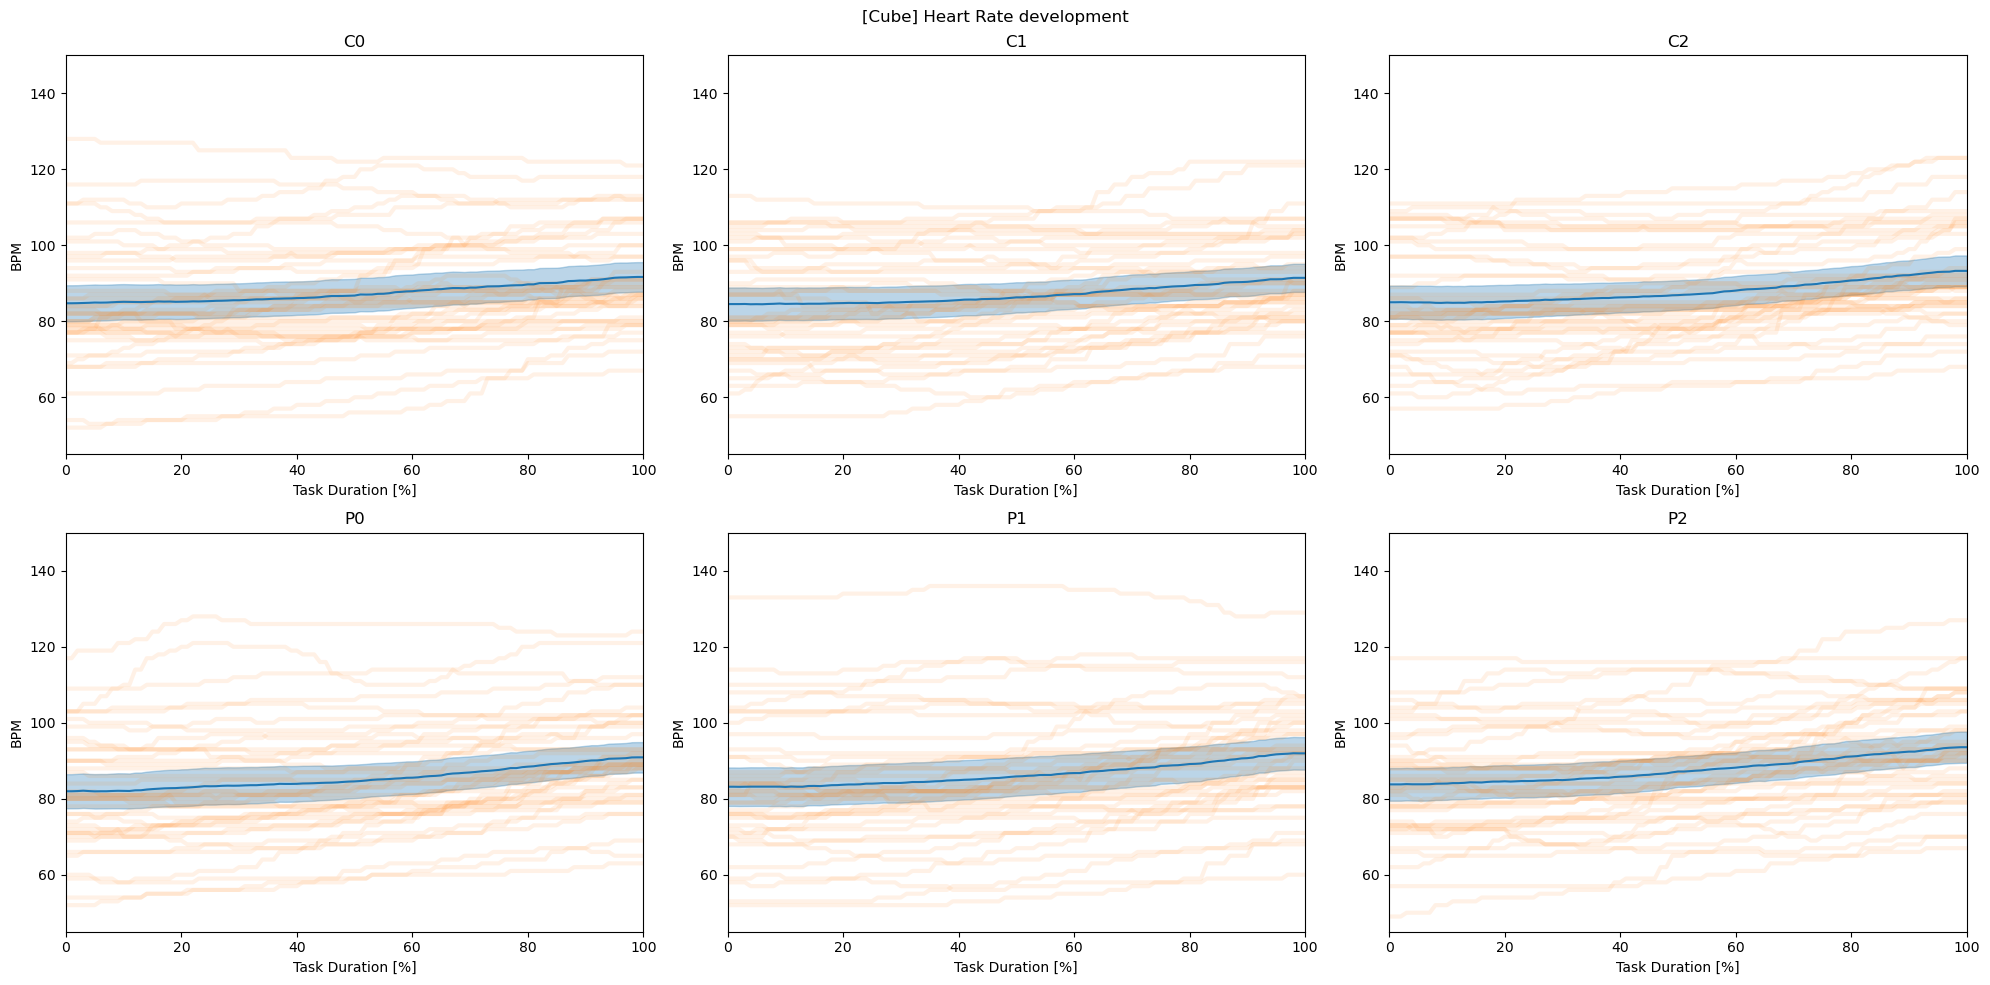

In [25]:
fig, axs = plt.subplots(2, 3, figsize=(20, 10))
ylim = [45,150]
ylabel = 'BPM'

plt.suptitle('[Cube] Heart Rate development')
normalized_curve(data, axs[0,0], cube, c_0, hr_key, ylim, ylabel)
normalized_curve(data, axs[0,1], cube, c_1, hr_key, ylim, ylabel)
normalized_curve(data, axs[0,2], cube, c_2, hr_key, ylim, ylabel)
normalized_curve(data, axs[1,0], cube, p_0, hr_key, ylim, ylabel)
normalized_curve(data, axs[1,1], cube, p_1, hr_key, ylim, ylabel)
normalized_curve(data, axs[1,2], cube, p_2, hr_key, ylim, ylabel)

fig.tight_layout()
plt.show()

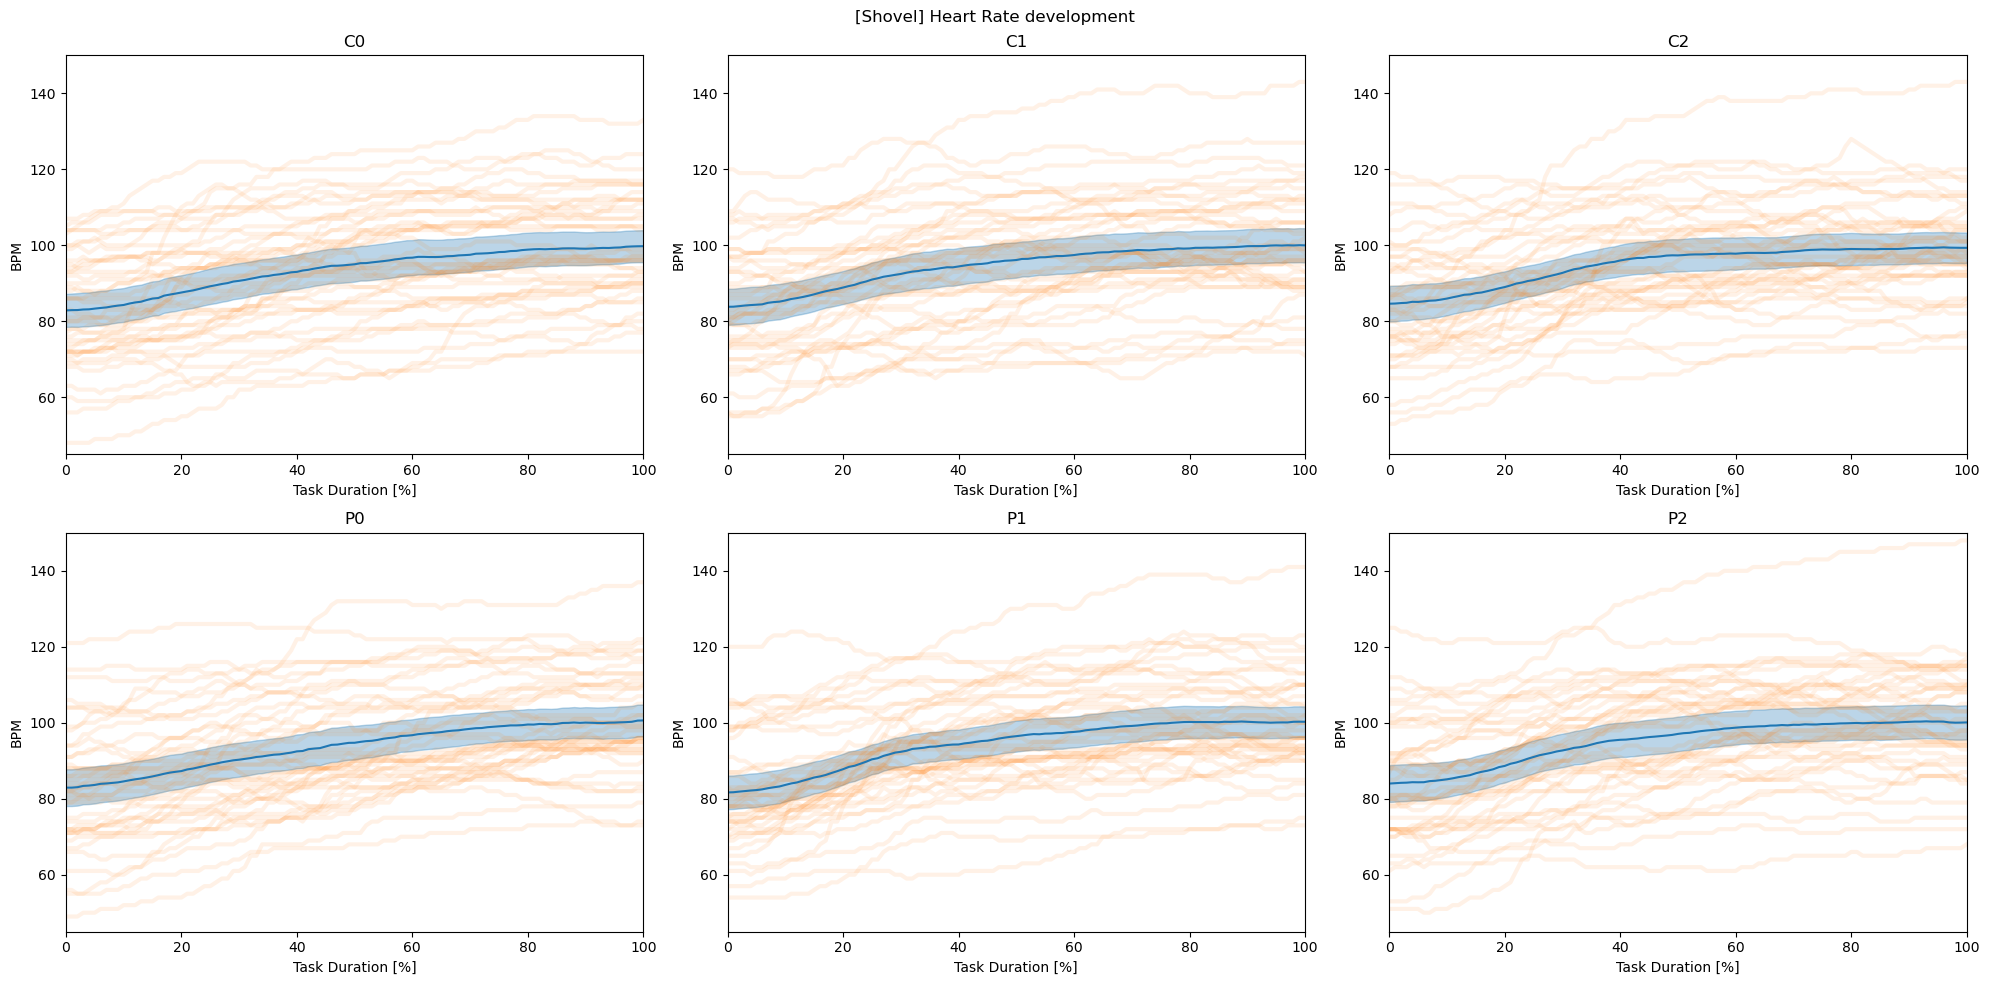

In [26]:
fig, axs = plt.subplots(2, 3, figsize=(20, 10))
ylim = [45,150]
ylabel = 'BPM'

plt.suptitle('[Shovel] Heart Rate development')
normalized_curve(data, axs[0,0], shovel, c_0, hr_key, ylim, ylabel)
normalized_curve(data, axs[0,1], shovel, c_1, hr_key, ylim, ylabel)
normalized_curve(data, axs[0,2], shovel, c_2, hr_key, ylim, ylabel)
normalized_curve(data, axs[1,0], shovel, p_0, hr_key, ylim, ylabel)
normalized_curve(data, axs[1,1], shovel, p_1, hr_key, ylim, ylabel)
normalized_curve(data, axs[1,2], shovel, p_2, hr_key, ylim, ylabel)

fig.tight_layout()
plt.show()

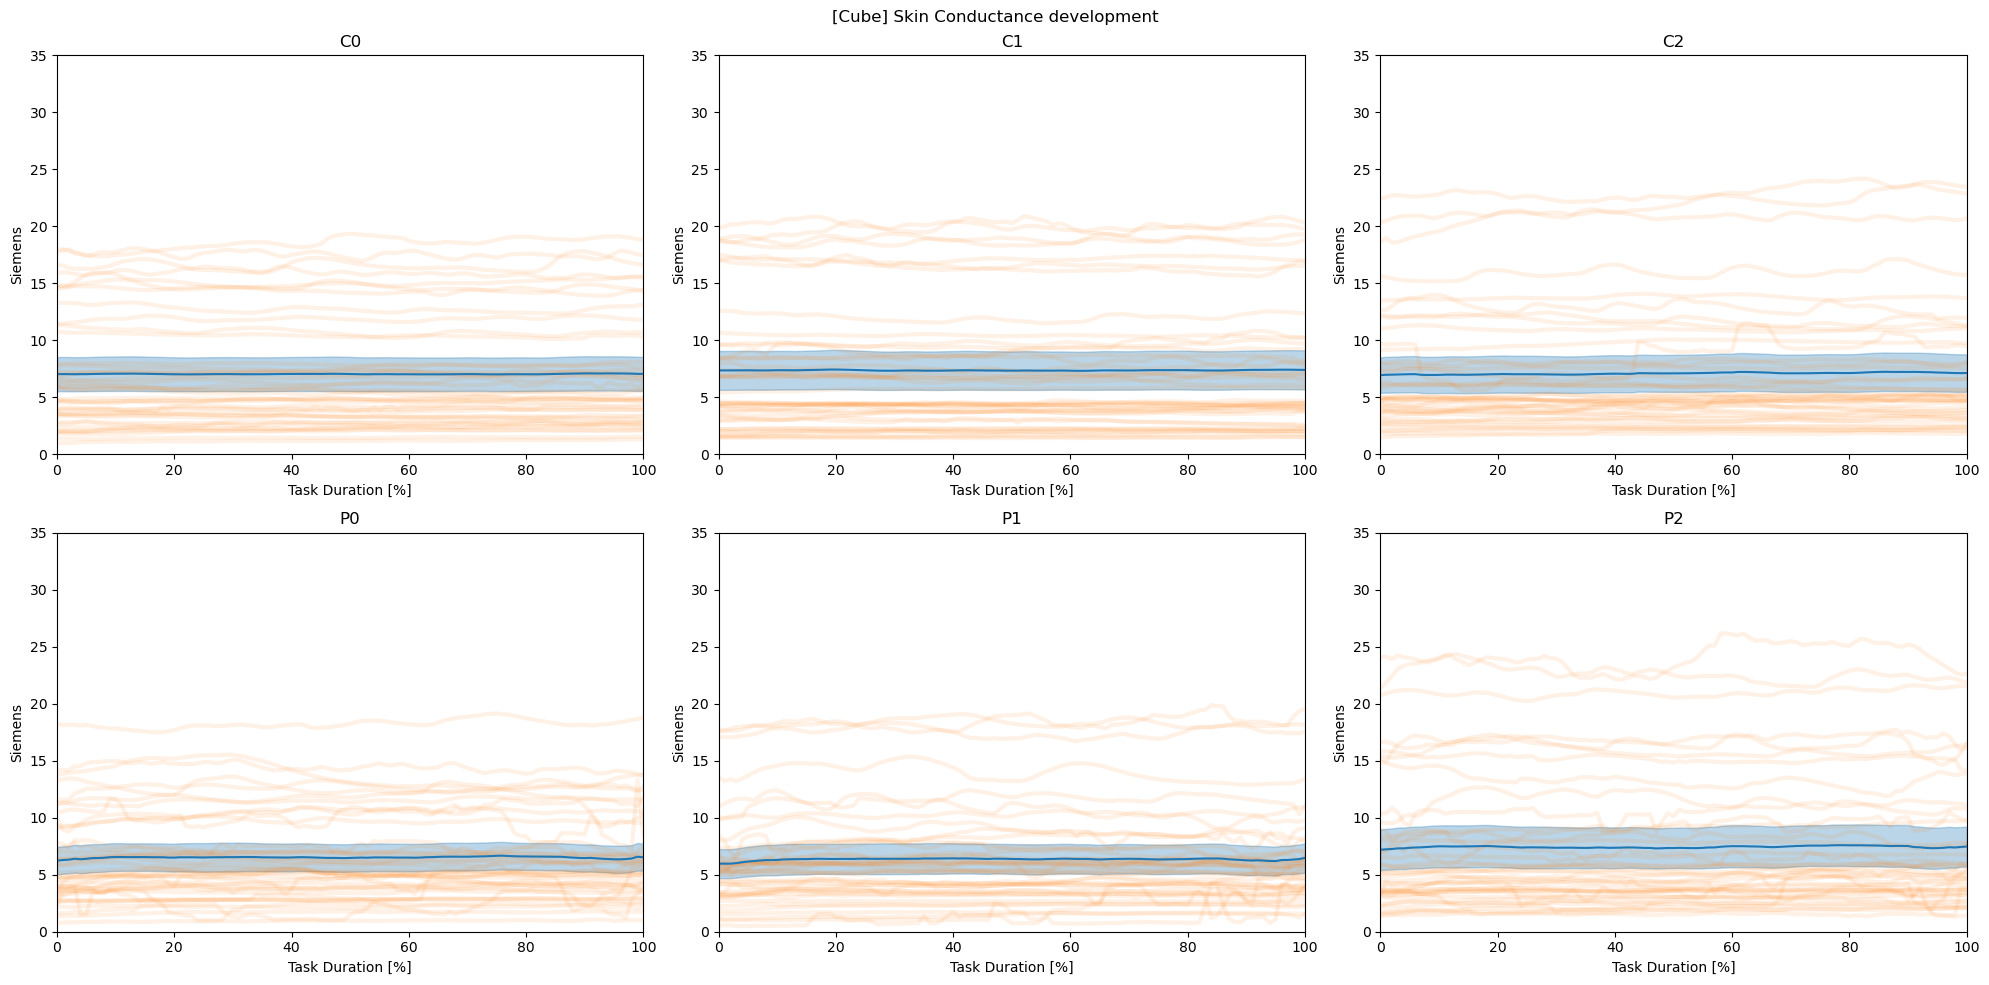

In [27]:
fig, axs = plt.subplots(2, 3, figsize=(20, 10))
ylim = [0,35]
ylabel = 'Siemens'

plt.suptitle('[Cube] Skin Conductance development')
normalized_curve(data, axs[0,0], cube, c_0, gsr_con_key, ylim, ylabel)
normalized_curve(data, axs[0,1], cube, c_1, gsr_con_key, ylim, ylabel)
normalized_curve(data, axs[0,2], cube, c_2, gsr_con_key, ylim, ylabel)
normalized_curve(data, axs[1,0], cube, p_0, gsr_con_key, ylim, ylabel)
normalized_curve(data, axs[1,1], cube, p_1, gsr_con_key, ylim, ylabel)
normalized_curve(data, axs[1,2], cube, p_2, gsr_con_key, ylim, ylabel)

fig.tight_layout()
plt.show()

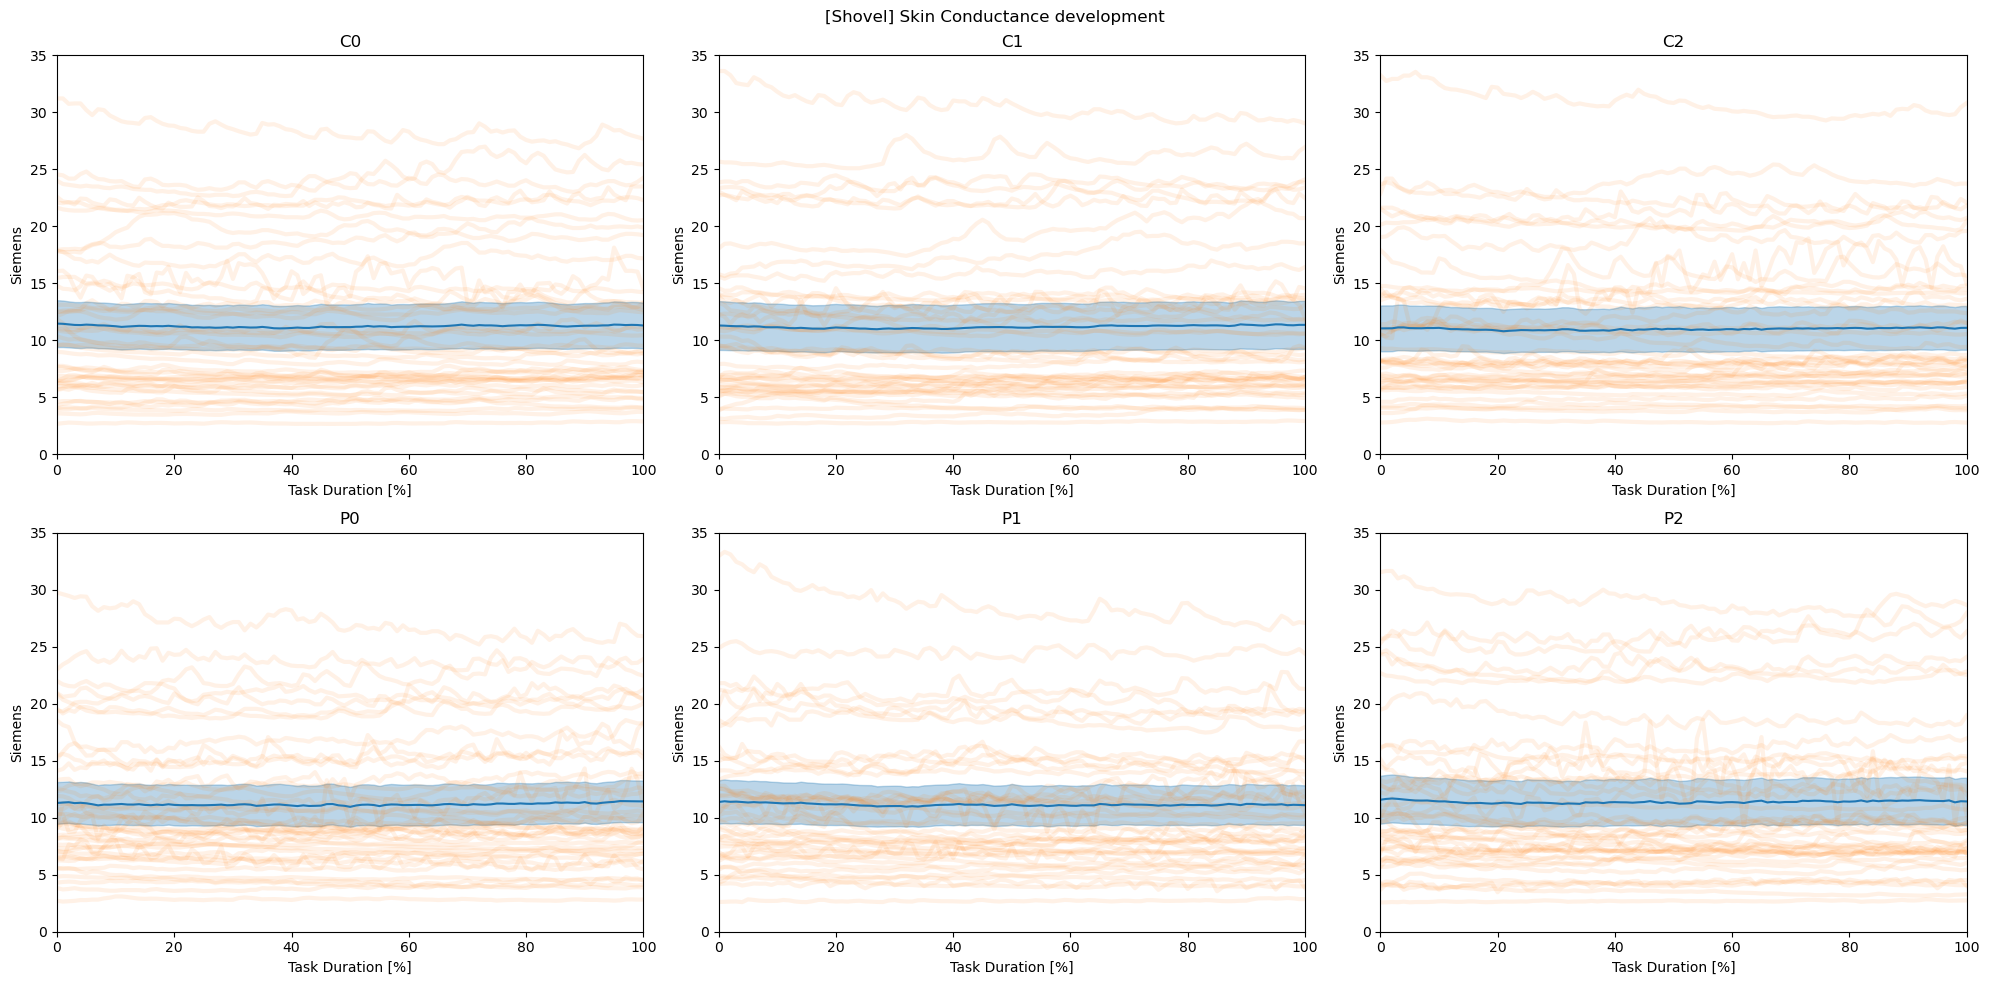

In [28]:
fig, axs = plt.subplots(2, 3, figsize=(20, 10))
ylim = [0,35]
ylabel = 'Siemens'

plt.suptitle('[Shovel] Skin Conductance development')
normalized_curve(data, axs[0,0], shovel, c_0, gsr_con_key, ylim, ylabel)
normalized_curve(data, axs[0,1], shovel, c_1, gsr_con_key, ylim, ylabel)
normalized_curve(data, axs[0,2], shovel, c_2, gsr_con_key, ylim, ylabel)
normalized_curve(data, axs[1,0], shovel, p_0, gsr_con_key, ylim, ylabel)
normalized_curve(data, axs[1,1], shovel, p_1, gsr_con_key, ylim, ylabel)
normalized_curve(data, axs[1,2], shovel, p_2, gsr_con_key, ylim, ylabel)

fig.tight_layout()
plt.show()

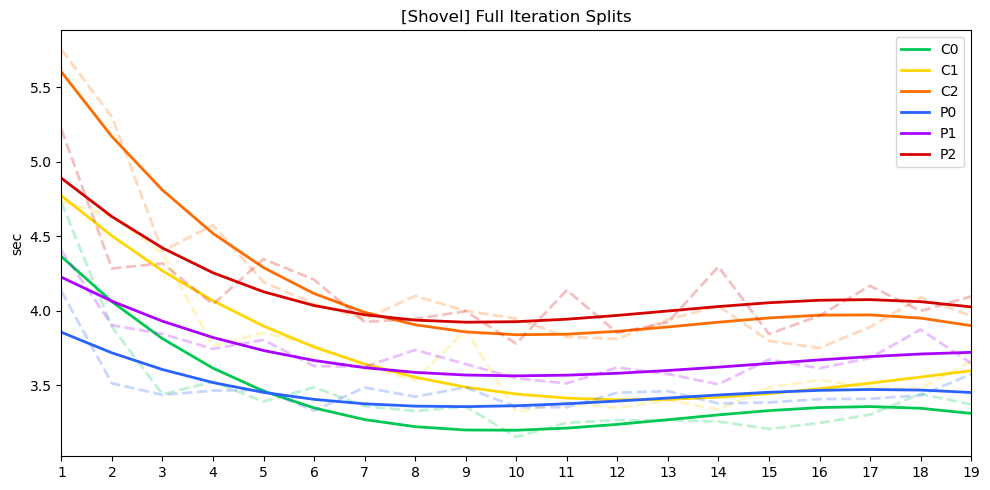

In [29]:
iterations = range(1, 20) # Exclude last iteration, as it is not complete (no return to pile)

def single_iteration_split (p):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])
    iteration_times = []
    for i in iterations:
        iteration = df[(df["collision_or_load_count"] == i)]
        time = (iteration[unity_unix_key].max() - iteration[unity_unix_key].min())/ 1_000
        iteration_times.append(time)
    return iteration_times

def get_shovel_iteration_splits(data, c):
    participants = list(map(lambda x: x[shovel][c], data))
    participant_splits = list(map(lambda x: single_iteration_split(x), participants))
    condition_splits = []
    for i in range(len(iterations)):
        split = []
        for j in range(len(participants)):
            split.append(participant_splits[j][i])
        condition_splits.append(split)
    split_means = list(map(lambda x: np.mean(x), condition_splits))
    return split_means

splits = list(map(lambda x: get_shovel_iteration_splits(data, x), conditions))

fig, ax = plt.subplots(figsize=(10, 5))

for i in range(len(conditions)):
    x = iterations
    y = splits[i]
    ax.plot(x, y, '--', lw=2, color=colors[i], alpha=0.25)
    z = np.polyfit(x, y, 3)
    p = np.poly1d(z)
    ax.plot(x, p(x), lw=2, color=colors[i], label=conditions[i])

ax.set_xticks(iterations)
ax.set_xlim([1,19])
ax.set_ylabel('sec')
ax.set_title('[Shovel] Full Iteration Splits')

ax.legend(loc='upper right', ncols=1)

fig.tight_layout()
plt.show()

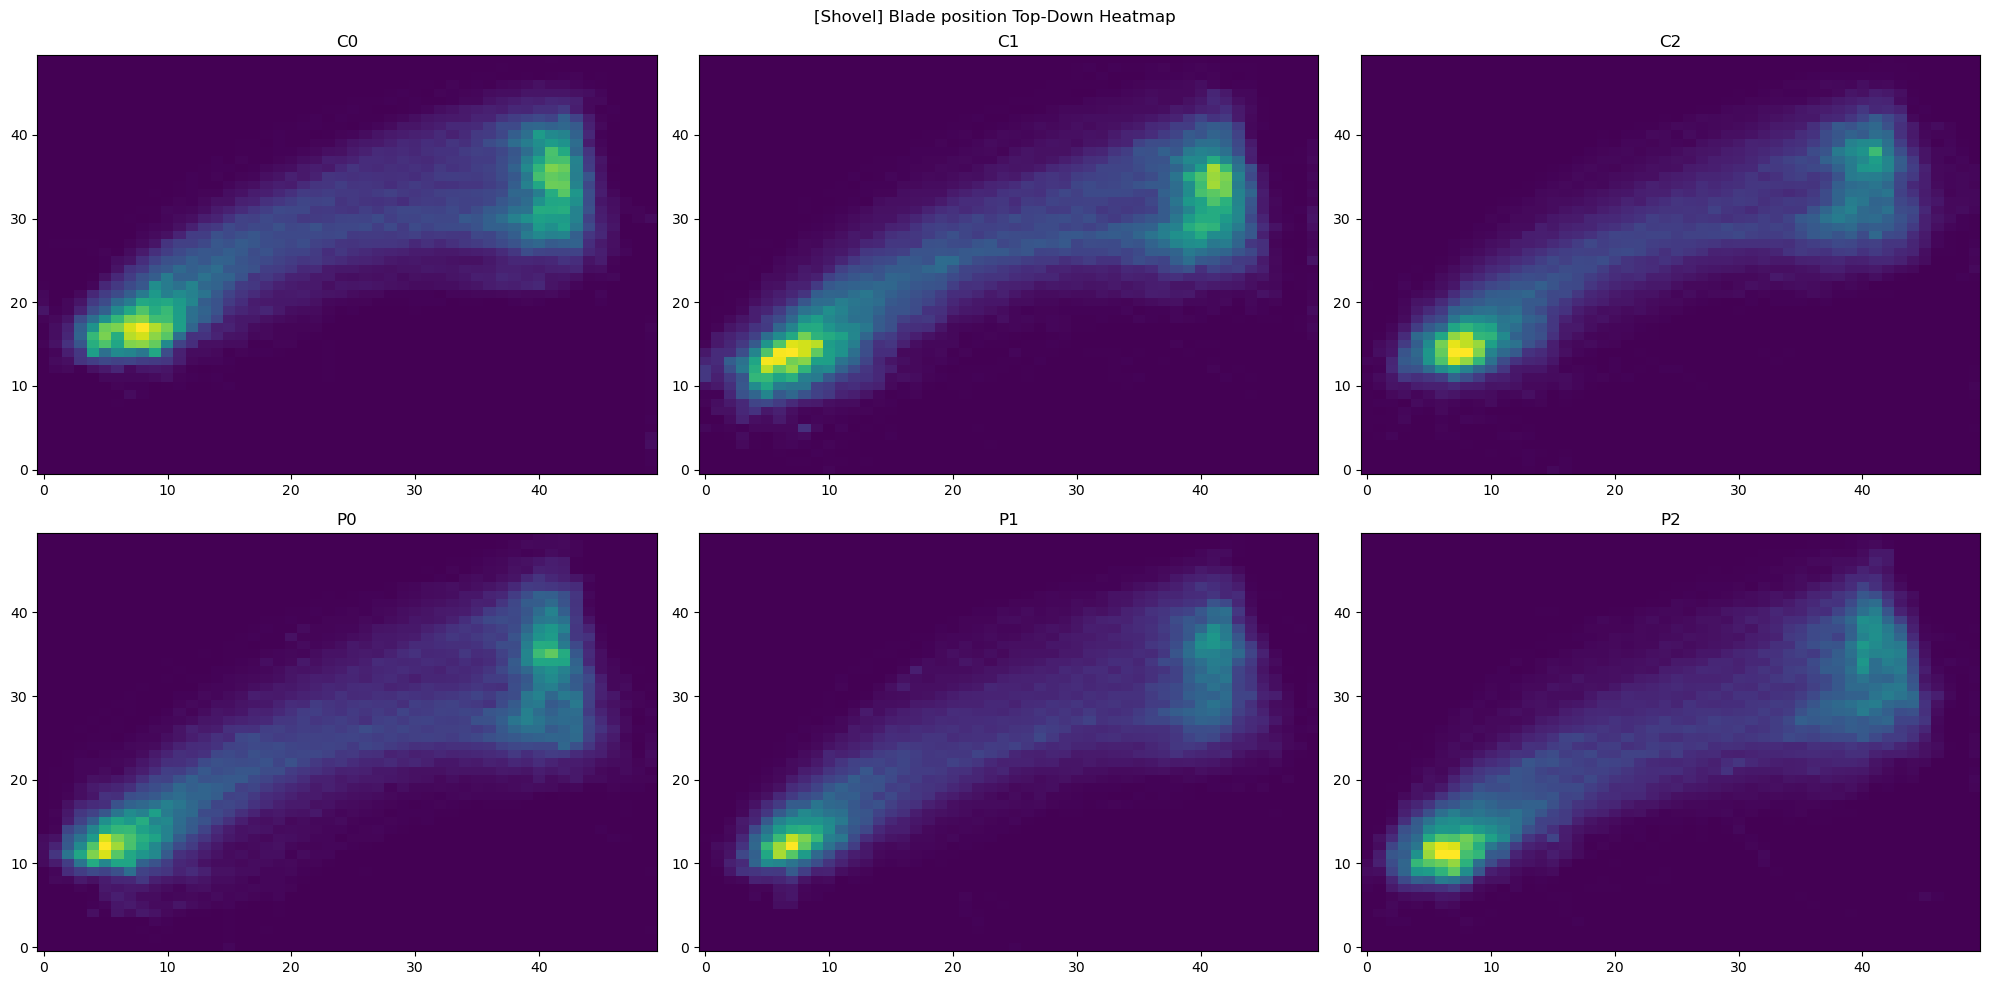

In [30]:
end_effector = 'ee'
primary_tracked = 'pt'
primary_visible = 'pv'
secondary_tracked = 'st'
secondary_visible = 'sv'
hmd = 'hmd'

tracking_pts = [end_effector, primary_tracked, primary_visible, secondary_tracked, secondary_visible, hmd]

def mirror_x(df, pt):
    key = pt + '_x'
    df[key] = df.apply(lambda x: -x[key] if x['primary_grab_hand'] == 'Left' else x[key], axis = 1)

def rectify_unity (p):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    for pt in tracking_pts:
        mirror_x(df, pt)

    return df

def top_heatmap(data, ax, e, c, pt):
    participants = list(map(lambda x: x[e][c], data))

    dfs = list(map(lambda x: rectify_unity(x), participants))
    all_values = pd.concat(dfs).sort_values(by=unified_delta_key)

    max_x = 0.25
    min_x = -1.75

    lateral = np.clip(list(all_values[pt + "_x"]), min_x, max_x)
    forward = list(all_values[pt + "_z"])
    vertical = list(all_values[pt + "_y"])

    heatmap, xedges, yedges = np.histogram2d(lateral, forward, bins=50)

    ax.title.set_text(c)
    ax.imshow(heatmap.T, origin='lower', cmap='viridis', aspect='auto')


fig, axs = plt.subplots(2, 3, figsize=(20, 10))
plt.suptitle('[Shovel] Blade position Top-Down Heatmap')

shovel_tip = 'ee'
secondary_hand = 'st'
primary_hand = 'pt'

top_heatmap(data, axs[0,0], shovel, c_0, shovel_tip)
top_heatmap(data, axs[0,1], shovel, c_1, shovel_tip)
top_heatmap(data, axs[0,2], shovel, c_2, shovel_tip)
top_heatmap(data, axs[1,0], shovel, p_0, shovel_tip)
top_heatmap(data, axs[1,1], shovel, p_1, shovel_tip)
top_heatmap(data, axs[1,2], shovel, p_2, shovel_tip)

plt.tight_layout()
plt.show()

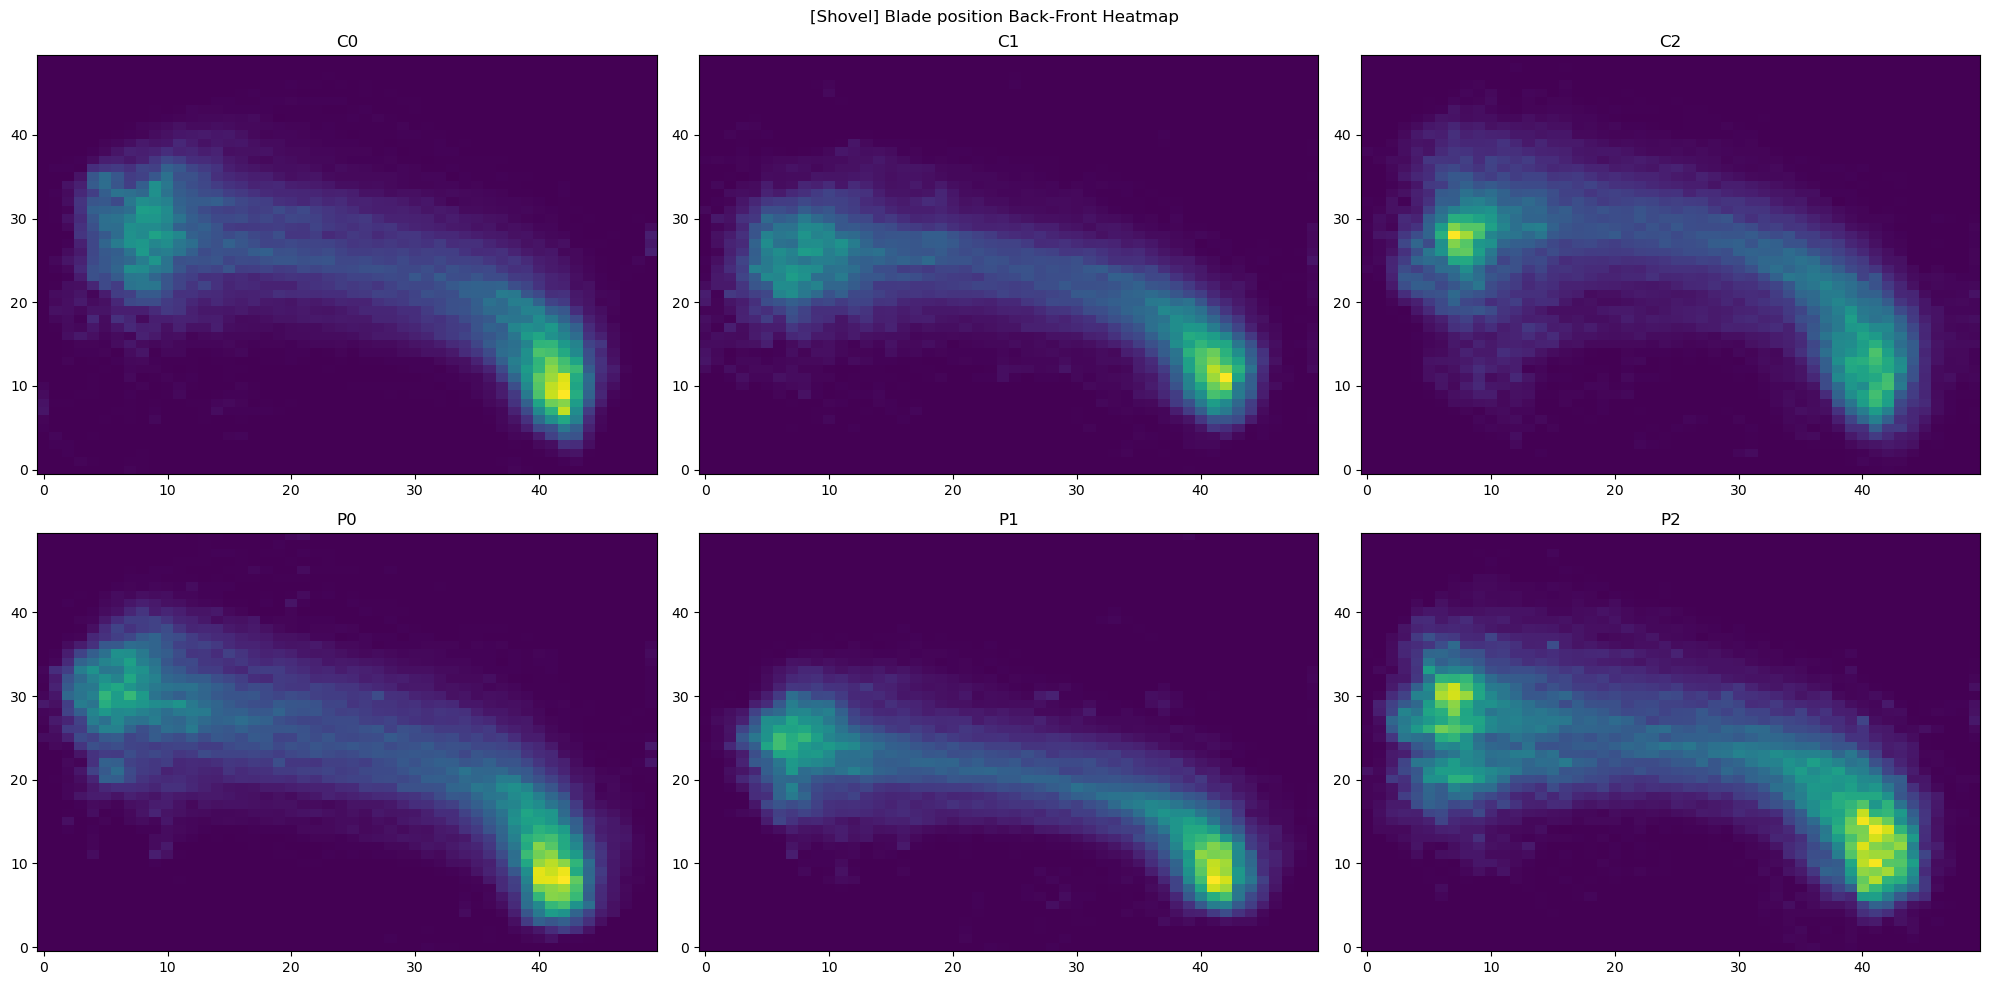

In [31]:
def front_heatmap(data, ax, e, c, pt):
    participants = list(map(lambda x: x[e][c], data))

    dfs = list(map(lambda x: rectify_unity(x), participants))
    all_values = pd.concat(dfs).sort_values(by=unified_delta_key)

    max_x = 0.25
    min_x = -1.75

    lateral = np.clip(list(all_values[pt + "_x"]), min_x, max_x)
    forward = list(all_values[pt + "_z"])
    vertical = list(all_values[pt + "_y"])

    heatmap, xedges, yedges = np.histogram2d(lateral, vertical, bins=50)

    ax.title.set_text(c)
    ax.imshow(heatmap.T, origin='lower', cmap='viridis', aspect='auto')


fig, axs = plt.subplots(2, 3, figsize=(20, 10))
plt.suptitle('[Shovel] Blade position Back-Front Heatmap')

shovel_tip = 'ee'
secondary_hand = 'st'
primary_hand = 'pt'

front_heatmap(data, axs[0,0], shovel, c_0, shovel_tip)
front_heatmap(data, axs[0,1], shovel, c_1, shovel_tip)
front_heatmap(data, axs[0,2], shovel, c_2, shovel_tip)
front_heatmap(data, axs[1,0], shovel, p_0, shovel_tip)
front_heatmap(data, axs[1,1], shovel, p_1, shovel_tip)
front_heatmap(data, axs[1,2], shovel, p_2, shovel_tip)

plt.tight_layout()
plt.show()

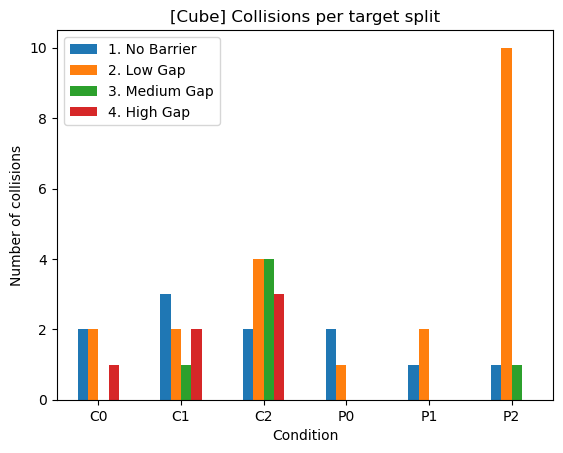

In [32]:
def single_collision_split(p):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    first = df[(df["cube_max_target_reached"] == 1)]
    second = df[(df["cube_max_target_reached"] == 2)]
    third = df[(df["cube_max_target_reached"] == 3)]
    fourth = df[(df["cube_max_target_reached"] == 4)]

    first_collisons =first["collision_or_load_count"].max() - first["collision_or_load_count"].min()
    second_collisons =second["collision_or_load_count"].max() - second["collision_or_load_count"].min()
    third_collisons =third["collision_or_load_count"].max() - third["collision_or_load_count"].min()
    fourth_collisons =fourth["collision_or_load_count"].max() - fourth["collision_or_load_count"].min()

    return [first_collisons, second_collisons, third_collisons, fourth_collisons]

def agg_collision_split(data, c):
    participants = list(map(lambda x: x[cube][c], data))

    splits = list(map(lambda x: single_collision_split(x), participants))
    
    first = list(map(lambda x: x[0],  splits))
    second = list(map(lambda x: x[1], splits))
    third = list(map(lambda x: x[2],  splits))
    fourth = list(map(lambda x: x[3], splits))
    
    return [np.sum(first), np.sum(second), np.sum(third), np.sum(fourth)]

condition_splits = list(map(lambda x: agg_collision_split(data, x), conditions))

df = pd.DataFrame(condition_splits, columns=["1. No Barrier", "2. Low Gap", "3. Medium Gap", "4. High Gap"], index = conditions)

df.plot(kind='bar', color=["tab:blue", "tab:orange", "tab:green", "tab:red"])

plt.title("[Cube] Collisions per target split")
plt.xlabel("Condition")
plt.ylabel("Number of collisions")

plt.gca().xaxis.set_tick_params(rotation=0)

plt.show()

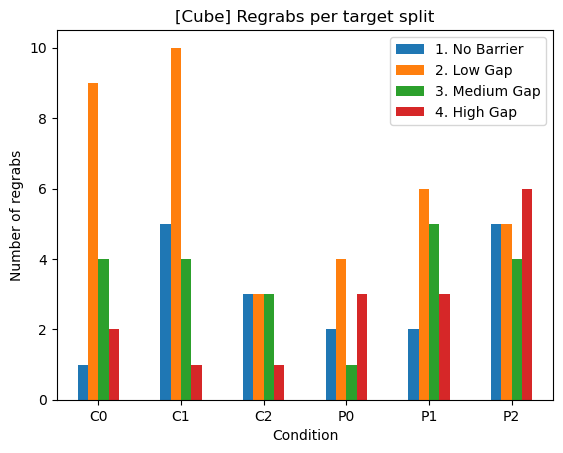

In [33]:
def single_grabcount_split(p):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    first = df[(df["cube_max_target_reached"] == 1)]
    second = df[(df["cube_max_target_reached"] == 2)]
    third = df[(df["cube_max_target_reached"] == 3)]
    fourth = df[(df["cube_max_target_reached"] == 4)]

    first_regrabs =first["grab_count"].max() - first["grab_count"].min()
    second_regrabs =second["grab_count"].max() - second["grab_count"].min()
    third_regrabs =third["grab_count"].max() - third["grab_count"].min()
    fourth_regrabs =fourth["grab_count"].max() - fourth["grab_count"].min()

    return [first_regrabs, second_regrabs, third_regrabs, fourth_regrabs]

def agg_grabcount_split(data, c):
    participants = list(map(lambda x: x[cube][c], data))

    splits = list(map(lambda x: single_grabcount_split(x), participants))
    
    first = list(map(lambda x: x[0],  splits))
    second = list(map(lambda x: x[1], splits))
    third = list(map(lambda x: x[2],  splits))
    fourth = list(map(lambda x: x[3], splits))
    
    return [np.sum(first), np.sum(second), np.sum(third), np.sum(fourth)]

condition_splits = list(map(lambda x: agg_grabcount_split(data, x), conditions))

df = pd.DataFrame(condition_splits, columns=["1. No Barrier", "2. Low Gap", "3. Medium Gap", "4. High Gap"], index = conditions)

df.plot(kind='bar', color=["tab:blue", "tab:orange", "tab:green", "tab:red"])

plt.title("[Cube] Regrabs per target split")
plt.xlabel("Condition")
plt.ylabel("Number of regrabs")

plt.gca().xaxis.set_tick_params(rotation=0)

plt.show()

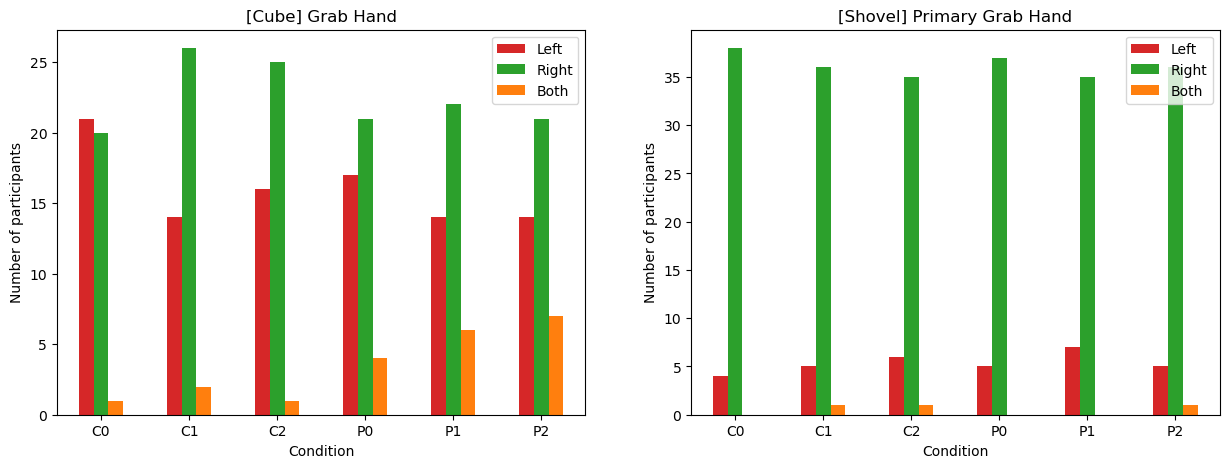

In [34]:
primary_left = "Left"
primary_right = "Right"
primary_both = "Both"
primary_none = "None"

primary_options = [primary_left, primary_right, primary_both]

def single_primary_hand(p):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    left = (df['primary_grab_hand'] == primary_left).any()
    right = (df['primary_grab_hand'] == primary_right).any()

    if left & right:
        return primary_both
    elif left:
        return primary_left
    elif right:
        return primary_right
    else:
        return primary_none

def agg_primary_hand(data, e, c):
    participants = list(map(lambda x: x[e][c], data))

    participant_hands = list(map(lambda x: single_primary_hand(x), participants))

    left = 0
    right = 0
    both = 0
    none = 0

    for i in range(len(participant_hands)):
        hands = participant_hands[i]

        if hands == primary_left:
            left += 1
        elif hands == primary_right:
            right += 1
        elif hands == primary_both:
            both += 1
        elif hands == primary_none:
            none += 1
    
    return [left, right, both]

cube_hands = list(map(lambda x: agg_primary_hand(data, cube, x), conditions))
cube_hands_df = pd.DataFrame(cube_hands, columns=primary_options, index = conditions)

shovel_hands = list(map(lambda x: agg_primary_hand(data, shovel, x), conditions))
shovel_hands_df = pd.DataFrame(shovel_hands, columns=primary_options, index = conditions)

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

cube_hands_df.plot(kind='bar', color=["tab:red", "tab:green", "tab:orange"], ax=axs[0])
axs[0].set_title('[Cube] Grab Hand')
axs[0].set_xlabel('Condition')
axs[0].set_ylabel('Number of participants')
axs[0].xaxis.set_tick_params(rotation=0)

shovel_hands_df.plot(kind='bar', color=["tab:red", "tab:green", "tab:orange"], ax=axs[1])
axs[1].set_title('[Shovel] Primary Grab Hand')
axs[1].set_xlabel('Condition')
axs[1].set_ylabel('Number of participants')
axs[1].xaxis.set_tick_params(rotation=0)

plt.show()

In [35]:
## -- Legacy Code

# --- Old GSR Resistance stuff (prefer conductance for reporting due to cleaner signal (and more significant results))

# def gsr_res_delta(p):
#     return pre_post_delta(p, gsr_res_key)

# title = 'GSR Resistance Delta'
# ylabel = 'Ohm'
# report_exeriment(data, gsr_res_delta, cube, title, ylabel)
# report_exeriment(data, gsr_res_delta, shovel, title, ylabel)

# def gsr_res_auc(p):
#     return normalized_auc(p, gsr_res_key)

# title = 'GSR Resistance AUC'
# ylabel = ''
# report_exeriment(data, gsr_res_auc, cube, title, ylabel)
# report_exeriment(data, gsr_res_auc, shovel, title, ylabel)

# fig, axs = plt.subplots(2, 3, figsize=(20, 10))
# ylim = [0,1000]
# ylabel = 'GSR Resistance [Ohm]'

# normalized_curve(data, axs[0,0], cube, c_0, gsr_res_key, ylim, ylabel)
# normalized_curve(data, axs[0,1], cube, c_1, gsr_res_key, ylim, ylabel)
# normalized_curve(data, axs[0,2], cube, c_2, gsr_res_key, ylim, ylabel)
# normalized_curve(data, axs[1,0], cube, p_0, gsr_res_key, ylim, ylabel)
# normalized_curve(data, axs[1,1], cube, p_1, gsr_res_key, ylim, ylabel)
# normalized_curve(data, axs[1,2], cube, p_2, gsr_res_key, ylim, ylabel)

# plt.show()

# fig, axs = plt.subplots(2, 3, figsize=(20, 10))
# ylim = [0,400]
# ylabel = 'GSR Resistance [Ohm]'

# normalized_curve(data, axs[0,0], shovel, c_0, gsr_res_key, ylim, ylabel)
# normalized_curve(data, axs[0,1], shovel, c_1, gsr_res_key, ylim, ylabel)
# normalized_curve(data, axs[0,2], shovel, c_2, gsr_res_key, ylim, ylabel)
# normalized_curve(data, axs[1,0], shovel, p_0, gsr_res_key, ylim, ylabel)
# normalized_curve(data, axs[1,1], shovel, p_1, gsr_res_key, ylim, ylabel)
# normalized_curve(data, axs[1,2], shovel, p_2, gsr_res_key, ylim, ylabel)

# plt.show()

# --- Old sensor data viz

# def agg_curve(data, ax, e, c, key, ylim, ylabel):
#     participants = list(map(lambda x: x[e][c], data))
#     trimmmed_dfs = list(map(lambda x: trim_df(x[imot], min_ts = x[start_ts] - baseline_ms, max_ts = x[end_ts] + baseline_ms), participants))
#     dfs = list(map(lambda x: remove_timeseries_outliers(x, key).set_index(unified_delta_key, drop = False), trimmmed_dfs))

#     max_duration = 155 if e == shovel else 90

#     ax.title.set_text(c + " [" + e + "] ")
#     ax.set_xlim([-30,max_duration])
#     ax.set_ylim(ylim)
#     ax.set_xlabel('sec')
#     ax.set_ylabel(ylabel)

#     sample_pts_ms = list(map(lambda x: x * 1000, range(-30, max_duration, 1)))
#     synced_samples = []
#     for i in sample_pts_ms:
#         sample_values = []
#         for df in dfs:
#             iloc_idx = df.index.get_indexer([i], method='nearest')  # returns absolute index into df e.g. array([5])  
#             nearest_row = df.iloc[iloc_idx[0]]
#             nearest_ms = nearest_row[unified_delta_key]
#             nearest_value = nearest_row[key]
#             if abs(nearest_ms - i) < 1_000:
#                 sample_values.append(nearest_value)
#             else:
#                 sample_values.append(np.nan)
#         synced_samples.append(sample_values)

#     #Individual
#     x = list(map(lambda x: x / 1000, sample_pts_ms))
#     for i in range(len(participants)):
#         participant_values = list(map(lambda x: x[i], synced_samples))
#         ax.plot(x, participant_values, color="tab:orange", alpha= 0.1, lw=3)

#     #Trend
#     min_agg_count = 6
#     valid_samples = list(map(lambda x: list(filter(lambda y: not np.isnan(y), x)), synced_samples))
#     agg_values = list(map(lambda x: [np.mean(x) if len(x) >= min_agg_count else np.nan, 1.96 * np.std(x) / np.sqrt(len(x))if len(x) >= min_agg_count else np.nan], valid_samples))
#     y_mean = list(map(lambda x: x[0], agg_values))
#     y_top = list(map(lambda x: x[0] + x[1] * 0.5, agg_values))
#     y_bottom = list(map(lambda x: x[0] - x[1] * 0.5, agg_values))
#     ax.plot(x, y_mean, color="tab:blue")
#     ax.fill_between(x,y_bottom, y_top, color='tab:blue', alpha=0.3)

#     #VLines
#     durations = list(map(lambda x: (x[end_ts] - x[start_ts]) / 1_000, participants))
#     min_end = np.min(durations)
#     max_end = np.max(durations)
#     end_quantiles = np.quantile(durations, q = np.arange(0.25, 1, 0.25))
#     q_1 = end_quantiles[0]
#     median = end_quantiles[1]
#     q_3 = end_quantiles[2]
#     ax.axvline(x=0, color='green', label='Start')
#     ax.axvline(x=min_end, color='red', linestyle='--', alpha= 0.3)
#     ax.axvline(x=median, color='red')
#     ax.axvline(x=max_end, color='red', linestyle='--', alpha= 0.3)
#     ymin, ymax = ax.get_ylim()
#     rect = patches.Rectangle((q_1, ymin), q_3-q_1, ymax-ymin, facecolor='red')
#     rect.set_alpha(0.3)
#     ax.add_patch(rect)

# fig, axs = plt.subplots(3, 2, figsize=(15, 15))
# ylim = [40,160]
# ylabel = 'Heart Rate [BPM]'

# agg_curve(data, axs[0,0], shovel, c_0, hr_key, ylim, ylabel)
# agg_curve(data, axs[1,0], shovel, c_1, hr_key, ylim, ylabel)
# agg_curve(data, axs[2,0], shovel, c_2, hr_key, ylim, ylabel)
# agg_curve(data, axs[0,1], shovel, p_0, hr_key, ylim, ylabel)
# agg_curve(data, axs[1,1], shovel, p_1, hr_key, ylim, ylabel)
# agg_curve(data, axs[2,1], shovel, p_2, hr_key, ylim, ylabel)

# plt.show()

# fig, axs = plt.subplots(3, 2, figsize=(15, 15))
# ylim = [40,160]
# ylabel = 'Heart Rate [BPM]'

# agg_curve(data, axs[0,0], cube, c_0, hr_key, ylim, ylabel)
# agg_curve(data, axs[1,0], cube, c_1, hr_key, ylim, ylabel)
# agg_curve(data, axs[2,0], cube, c_2, hr_key, ylim, ylabel)
# agg_curve(data, axs[0,1], cube, p_0, hr_key, ylim, ylabel)
# agg_curve(data, axs[1,1], cube, p_1, hr_key, ylim, ylabel)
# agg_curve(data, axs[2,1], cube, p_2, hr_key, ylim, ylabel)

# plt.show()

# fig, axs = plt.subplots(3, 2, figsize=(15, 15))
# ylim = [0,2500]
# ylabel = 'GSR Resistance [Ohm]'

# agg_curve(data, axs[0,0], cube, c_0, gsr_res_key, ylim, ylabel)
# agg_curve(data, axs[1,0], cube, c_1, gsr_res_key, ylim, ylabel)
# agg_curve(data, axs[2,0], cube, c_2, gsr_res_key, ylim, ylabel)
# agg_curve(data, axs[0,1], cube, p_0, gsr_res_key, ylim, ylabel)
# agg_curve(data, axs[1,1], cube, p_1, gsr_res_key, ylim, ylabel)
# agg_curve(data, axs[2,1], cube, p_2, gsr_res_key, ylim, ylabel)

# plt.show()

# fig, axs = plt.subplots(3, 2, figsize=(15, 15))
# ylim = [0,700]
# ylabel = 'GSR Resistance [Ohm]'

# agg_curve(data, axs[0,0], shovel, c_0, gsr_res_key, ylim, ylabel)
# agg_curve(data, axs[1,0], shovel, c_1, gsr_res_key, ylim, ylabel)
# agg_curve(data, axs[2,0], shovel, c_2, gsr_res_key, ylim, ylabel)
# agg_curve(data, axs[0,1], shovel, p_0, gsr_res_key, ylim, ylabel)
# agg_curve(data, axs[1,1], shovel, p_1, gsr_res_key, ylim, ylabel)
# agg_curve(data, axs[2,1], shovel, p_2, gsr_res_key, ylim, ylabel)

# plt.show()

# fig, axs = plt.subplots(3, 2, figsize=(15, 15))
# ylim = [0,30]
# ylabel = 'GSR Conductance [Siemens]'

# agg_curve(data, axs[0,0], cube, c_0, gsr_con_key, ylim, ylabel)
# agg_curve(data, axs[1,0], cube, c_1, gsr_con_key, ylim, ylabel)
# agg_curve(data, axs[2,0], cube, c_2, gsr_con_key, ylim, ylabel)
# agg_curve(data, axs[0,1], cube, p_0, gsr_con_key, ylim, ylabel)
# agg_curve(data, axs[1,1], cube, p_1, gsr_con_key, ylim, ylabel)
# agg_curve(data, axs[2,1], cube, p_2, gsr_con_key, ylim, ylabel)

# plt.show()

# fig, axs = plt.subplots(3, 2, figsize=(15, 15))
# ylim = [0,40]
# ylabel = 'GSR Conductance [Siemens]'

# agg_curve(data, axs[0,0], shovel, c_0, gsr_con_key, ylim, ylabel)
# agg_curve(data, axs[1,0], shovel, c_1, gsr_con_key, ylim, ylabel)
# agg_curve(data, axs[2,0], shovel, c_2, gsr_con_key, ylim, ylabel)
# agg_curve(data, axs[0,1], shovel, p_0, gsr_con_key, ylim, ylabel)
# agg_curve(data, axs[1,1], shovel, p_1, gsr_con_key, ylim, ylabel)
# agg_curve(data, axs[2,1], shovel, p_2, gsr_con_key, ylim, ylabel)

# plt.show()

# --- Trajectory 3D Scatter viz

# def scatter_3D(data, fig, index, e, c, pt):
#     participants = list(map(lambda x: x[e][c], data))

#     dfs = list(map(lambda x: rectify_unity(x), participants))
#     all_values = pd.concat(dfs).sort_values(by=unified_delta_key)

#     max_x = 0.25
#     min_x = -1.75

#     lateral = list(all_values[pt + "_x"])
#     forward = list(all_values[pt + "_z"])
#     vertical = list(all_values[pt + "_y"])

#     # Create a figure and 3D axis
#     # fig = plt.figure(figsize=(8,6))
#     # ax = fig.add_subplot(111, projection='3d')
#     ax = fig.add_subplot(1, 2, index, projection='3d')

#     ax.set_zlim(0, 1.5)
#     ax.set_xlim(-2, 0.5)
#     ax.set_ylim(-0.5, 2)

#     # Create scatter plot
#     ax.scatter3D(lateral, forward, vertical, color='tab:blue', alpha=0.01, s=0.5)



#     # Labels
#     ax.set_xlabel('Lateral')
#     ax.set_ylabel('Forward')
#     ax.set_zlabel('Vertical')
#     ax.set_title(c)


# fig = plt.figure(figsize=plt.figaspect(0.25))

# shovel_tip = 'ee'
# secondary_hand = 'st'
# primary_hand = 'pt'

# scatter_3D(data, fig, 1, shovel, c_0, shovel_tip)
# scatter_3D(data, fig, 2, shovel, c_1, shovel_tip)
# scatter_3D(data, fig, 3, shovel, c_2, shovel_tip)
# scatter_3D(data, fig, 4, shovel, p_0, shovel_tip)
# scatter_3D(data, fig, 5, shovel, p_1, shovel_tip)
# scatter_3D(data, fig, 6, shovel, p_2, shovel_tip)

# plt.show()


# --- Old ttest-based significance bracket plotting logic

# def plot_significance_brackets(ax, scale, barheights, pairwise):
#     contrast = "Contrast"
#     p_corr = "p-corr"
#     p_unc = "p-unc"

#     significant_pairwise = get_significant_entries(pairwise)

#     n_bars = np.arange(len(conditions))

#     offset_step = (scale[1] - scale[0]) / 10
#     bracket_height = offset_step * 0.25
#     fixed_heights =  [np.max(barheights) + bracket_height*2] * len(conditions)

#     current_offset = 0

#     individual = significant_pairwise[significant_pairwise[contrast] == device_x_scaling_key]
#     individual_next = individual.loc[(individual['A'] != "0") | (individual['B'] != "2")]
#     if individual_next.shape[0] > 0:
#         for index, row in individual_next.iterrows():
#             a = int(row["A"])
#             b = int(row["B"])
#             if row[device_key] == "P":
#                 a += 3
#                 b += 3
#             barplot_annotate_brackets(ax, a, b, row[p_corr], n_bars, fixed_heights, offset= current_offset, height=bracket_height)
#         current_offset += offset_step

#     individual_spanning = individual.loc[(individual['A'] == "0") & (individual['B'] == "2")]
#     if individual_spanning.shape[0] > 0:
#         for index, row in individual_spanning.iterrows():
#             a = int(row["A"])
#             b = int(row["B"])
#             if row[device_key] == "P":
#                 a += 3
#                 b += 3
#             barplot_annotate_brackets(ax, a, b, row[p_corr], n_bars, fixed_heights, offset= current_offset, height=bracket_height)
#         current_offset += offset_step

#     scaling = significant_pairwise[significant_pairwise[contrast] == scaling_key]
#     scaling_next = scaling.loc[(scaling['A'] != "0") | (scaling['B'] != "2")]
#     if scaling_next.shape[0] > 0:
#         for index, row in scaling_next.iterrows():
#             a = int(row["A"])
#             b = int(row["B"])
#             text = row["A"] + "-" + row["B"]
#             barplot_annotate_brackets(ax, a, b, row[p_corr], n_bars, fixed_heights, offset= current_offset, height=bracket_height, addtext=text, color="tab:orange")
#         current_offset += offset_step

#     scaling_spanning = scaling.loc[(scaling['A'] == "0") & (scaling['B'] == "2")]
#     if scaling_spanning.shape[0] > 0:
#         for index, row in scaling_spanning.iterrows():
#             a = int(row["A"])
#             b = int(row["B"])
#             text = row["A"] + "-" + row["B"]
#             barplot_annotate_brackets(ax, a, b, row[p_corr], n_bars, fixed_heights, offset= current_offset, height=bracket_height, addtext=text, color="tab:orange")
#         current_offset += offset_step


#     device = significant_pairwise[significant_pairwise[contrast] == device_key]
#     if device.shape[0] > 0:
#         for index, row in device.iterrows():
#             barplot_annotate_brackets(ax, 0, 3, row[p_unc], n_bars, fixed_heights, offset=current_offset, height=bracket_height, addtext="C-P", color="tab:blue")
#         current_offset += offset_step

#     # Set axis limits to provided scale or max bracket height if higher
#     ax.set_ylim([scale[0], np.max([fixed_heights[0]+current_offset, scale[1]])])